
# 21-Symbolic-Computation-with-SymPy

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/01-Foundations/21_Symbolic_Computation_with_SymPy.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=01-Foundations/21_Symbolic_Computation_with_SymPy.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# --- Global Notebook Setup ---
import warnings

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Apply the standard course style for all plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "lines.markersize": 6,
    }
)
%config InlineBackend.figure_format = 'retina'  # High-res plots

sp.init_printing(use_latex="mathjax")  # Better symbolic printing
warnings.filterwarnings("ignore", category=FutureWarning)


### Table of Contents
1. [The Lens: Symbolic vs. Numerical Computation](#The-Lens:-Symbolic-vs.-Numerical-Computation)
2. [Core Concepts: Symbols and Expressions](#Core-Concepts:-Symbols-and-Expressions)
3. [Symbolic Calculus](#Symbolic-Calculus)
    - [Differentiation](#Differentiation)
    - [Integration](#Integration)
    - [Limits](#Limits)
4. [Solving Equations](#Solving-Equations)
    - [Algebraic Equations](#Algebraic-Equations)
    - [Systems of Equations](#Systems-of-Equations)
    - [Deriving the Euler Equation](#Deriving-the-Euler-Equation)
5. [Application: Consumer Utility Maximization](#Application:-Consumer-Utility-Maximization)
6. [From Symbols to Numbers: `lambdify`](#From-Symbols-to-Numbers:-lambdify)
7. [Summary](#Summary)
8. [Exercises](#Exercises)


## The Lens: 21-Symbolic-Computation-with-SymPy
So far, we have focused on **numerical computation**: using arrays of numbers to approximate solutions. While powerful, this approach has limitations. It gives you an answer for *specific* parameter values, but it doesn't tell you the general relationship. It can tell you that "if price is 5, demand is 10", but not "demand is inversely proportional to price squared".

**Symbolic computation** (or Computer Algebra) manipulates mathematical expressions directly, just as you would on paper. It allows you to:
- Derive analytical solutions (e.g., specific functional forms for optimal policy).
- Calculate exact derivatives without approximation error.
- Simplify complex algebraic expressions.

**SymPy** is Python's library for symbolic mathematics. For an economist, it acts as a digital research assistant, automating the tedious algebra involved in deriving first-order conditions, solving theoretical models, and verifying analytical results.


**Economic question.** In *21-Symbolic-Computation-with-SymPy*, what must remain economically invariant when the computational representation changes? The economic value of this topic is not the syntax itself but the reliability of the research workflow it enables. Small implementation choices determine whether a result can be reproduced, scaled to a panel or simulation, and audited by another researcher. As you work through the examples, ask which representation makes the economic object easiest to validate and which failure modes would silently change a quantitative conclusion.

### Learning Objectives
* **Define** symbolic variables and expressions, then simplify and expand algebraically.
* **Solve** equations, compute derivatives, integrals, and limits symbolically.
* **Convert** symbolic results to NumPy-compatible functions with `lambdify`.

### Prerequisites
* **NumPy:** Numerical array operations for comparison (Module 01 - NumPy).
* **Calculus:** Differentiation, integration, and Taylor series.
* **Learning-path prerequisite:** [`20_Introduction_to_SciPy.ipynb`](20_Introduction_to_SciPy.ipynb)


> **Learning path:** Building on [`20_Introduction_to_SciPy.ipynb`](20_Introduction_to_SciPy.ipynb); next continue with [`22A_Computational_Complexity_Foundations.ipynb`](22A_Computational_Complexity_Foundations.ipynb).


### Core Concepts: Symbols and Expressions

In standard Python, `x = y + z` calculates a value immediately. In SymPy, we define `x`, `y`, and `z` as abstract symbols. Operations on them build up a symbolic expression tree rather than calculating a number.


In [2]:
# Define symbols
x, y, z = sp.symbols("x y z")

# Create a symbolic expression
expr = x**2 + 2 * y + z

print("Symbolic Expression:")
display(expr)

print("\nEvaluating the expression at specific values:")
display(expr.subs({x: 2, y: 1, z: 3}))


Symbolic Expression:


 2          
x  + 2⋅y + z


Evaluating the expression at specific values:


9

### Symbolic Calculus

SymPy excels at calculus. It can calculate derivatives, integrals, and limits symbolically.


#### Differentiation
Calculating marginal utility, marginal cost, or the gradient of a likelihood function is a one-line operation.


In [3]:
expr = sp.sin(x) * sp.exp(x)

print("Expression:")
display(expr)

print("\nDerivative w.r.t x:")
diff_expr = sp.diff(expr, x)
display(diff_expr)

print("\nSecond Derivative w.r.t x:")
display(sp.diff(expr, x, 2))


Expression:


 x       
ℯ ⋅sin(x)


Derivative w.r.t x:


 x           x       
ℯ ⋅sin(x) + ℯ ⋅cos(x)


Second Derivative w.r.t x:


   x       
2⋅ℯ ⋅cos(x)

#### Integration
SymPy can perform both indefinite and definite integration.


In [4]:
print("Indefinite Integral of the derivative (should recover original function):")
int_expr = sp.integrate(diff_expr, x)
display(int_expr)

print("\nDefinite Integral from 0 to pi:")
def_int = sp.integrate(sp.sin(x), (x, 0, sp.pi))
display(def_int)


Indefinite Integral of the derivative (should recover original function):


 x       
ℯ ⋅sin(x)


Definite Integral from 0 to pi:


2

### Solving Equations

SymPy can solve algebraic equations and systems of equations symbolically. Note that `sp.solve` expects expressions equal to zero.


In [5]:
print("Solving x^2 - 4 = 0 for x:")
solution = sp.solve(x**2 - 4, x)
display(solution)


Solving x^2 - 4 = 0 for x:


[-2, 2]

#### Deriving the Euler Equation

A key task in macroeconomics is deriving the Euler equation for intertemporal optimization. We can use SymPy to find the FOCs of the Lagrangian for a two-period consumption/savings problem.

Problem: Maximize $u(c_1) + \beta u(c_2)$ subject to $c_1 + c_2/(1+r) = W$.


In [6]:
c1, c2, r, beta, W, lam = sp.symbols("c1 c2 r beta W lambda", positive=True)

# Utility functions (CRRA example: u(c) = c^(1-sigma)/(1-sigma))
sigma = sp.symbols("sigma", positive=True)
u1 = c1**(1-sigma) / (1-sigma)
u2 = c2**(1-sigma) / (1-sigma)

# Lagrangian
L = u1 + beta * u2 + lam * (W - c1 - c2 / (1 + r))

# FOCs
foc1 = sp.diff(L, c1)
foc2 = sp.diff(L, c2)

# Solve for lambda from FOC 1
lam_sol = sp.solve(foc1, lam)[0]

# Substitute lambda into FOC 2 and simplify to get the Euler Equation
euler_raw = foc2.subs(lam, lam_sol)
print("Raw Euler Equation (FOC 2 with lambda substituted):")
display(euler_raw)

print("Simplified Euler Equation (Ratio of Marginal Utilities):")
# Rearrange to show MU(c1) / MU(c2) = beta * (1+r)
mu1 = sp.diff(u1, c1)
mu2 = sp.diff(u2, c2)
relation = sp.Eq(mu2 / mu1, 1 / (beta * (1 + r)))
display(relation)


Raw Euler Equation (FOC 2 with lambda substituted):


    1 - σ     -σ 
β⋅c₂        c₁   
───────── - ─────
   c₂       r + 1

Simplified Euler Equation (Ratio of Marginal Utilities):


     σ - 1   1 - σ            
c₁⋅c₁     ⋅c₂            1    
────────────────── = ─────────
        c₂           β⋅(r + 1)

### Application: Consumer Utility Maximization

Let's solve a classic problem: deriving the Marshallian demand functions for a consumer with Cobb-Douglas preferences $U(x_1, x_2) = x_1^\alpha x_2^{1-\alpha}$ subject to a budget constraint $p_1 x_1 + p_2 x_2 = I$.


In [7]:
# Define positive symbols for economic variables
x1, x2, p1, p2, I = sp.symbols("x1 x2 p1 p2 I", positive=True)
alpha = sp.symbols("alpha", positive=True)
lam = sp.symbols("lambda")

# Utility function
U = (x1**alpha) * (x2 ** (1 - alpha))

# Budget constraint: I - p1*x1 - p2*x2 = 0
budget = I - p1 * x1 - p2 * x2

# Lagrangian
L = U + lam * budget

# First-Order Conditions
foc_x1 = sp.diff(L, x1)
foc_x2 = sp.diff(L, x2)
foc_lam = sp.diff(L, lam)

print("First Order Conditions:")
display(sp.Eq(foc_x1, 0))
display(sp.Eq(foc_x2, 0))
display(sp.Eq(foc_lam, 0))

print("\nSolving the system for x1, x2, and lambda:")
sol = sp.solve([foc_x1, foc_x2, foc_lam], [x1, x2, lam])

# The result is a list of solutions (dictionaries). We take the first one.
optimal_bundle = sol[0]

print("Optimal x1 (Marshallian Demand):")
display(optimal_bundle[0])

print("Optimal x2 (Marshallian Demand):")
display(optimal_bundle[1])


First Order Conditions:


    α   1 - α           
α⋅x₁ ⋅x₂                
───────────── - λ⋅p₁ = 0
     x₁                 

          α   1 - α            
        x₁ ⋅x₂     ⋅(1 - α)    
-λ⋅p₂ + ─────────────────── = 0
                x₂             

I - p₁⋅x₁ - p₂⋅x₂ = 0


Solving the system for x1, x2, and lambda:


Optimal x1 (Marshallian Demand):


I⋅α
───
p₁ 

Optimal x2 (Marshallian Demand):


I⋅(1 - α)
─────────
   p₂    

### From Symbols to Numbers: `lambdify`

Once you have derived a symbolic solution (like the demand function above), you often want to use it in a numerical simulation. SymPy's `lambdify` function bridges this gap. It compiles a SymPy expression into a fast NumPy-compatible Python function.


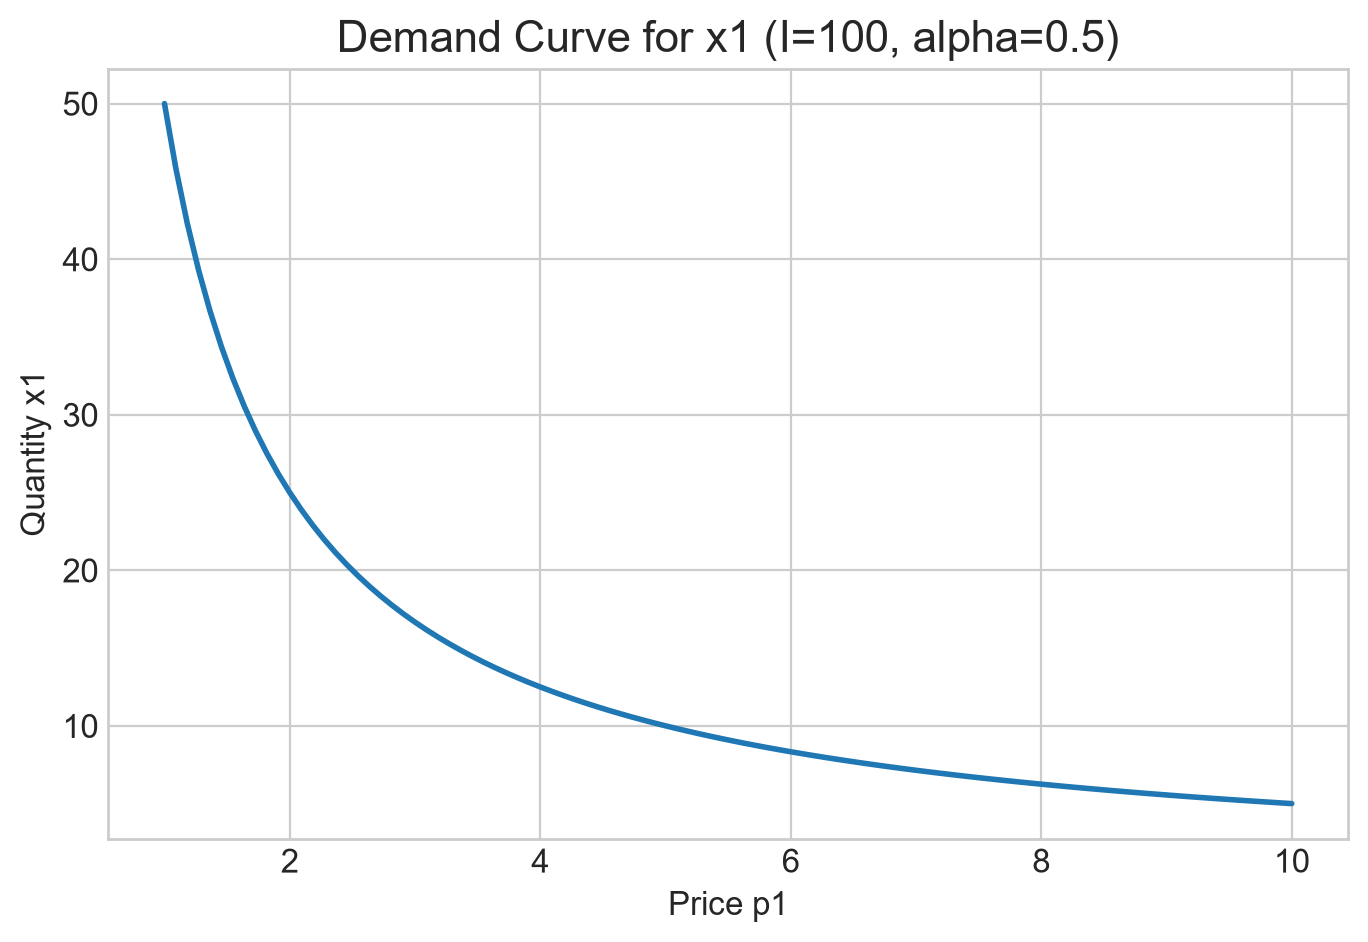

In [8]:
# Turn the symbolic demand for x1 into a python function
demand_x1_func = sp.lambdify((I, p1, alpha), optimal_bundle[0], modules="numpy")

# Now we can use it with NumPy arrays
prices = np.linspace(1, 10, 100)
income = 100
pref_alpha = 0.5

quantities = demand_x1_func(income, prices, pref_alpha)

plt.figure(figsize=(8, 5))
plt.plot(prices, quantities)
plt.title(f"Demand Curve for x1 (I={income}, alpha={pref_alpha})")
plt.xlabel("Price p1")
plt.ylabel("Quantity x1")
plt.show()


### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Explain the central computational idea in **21-Symbolic-Computation-with-SymPy** and connect it to one explicit economic object or research workflow.

**2. Reproduce and diagnose (Applied):** Reproduce an example involving Core Concepts: Symbols and Expressions, Symbolic Calculus, then change one input and explain the result before running the code.

**3. Robust extension (Challenge):** Extend the example to a larger or less convenient case and document the correctness and performance checks needed before trusting the result.

**3b. Failure analysis (Challenge):** `solve` returns an empty list for an equation that clearly has solutions, and a symbolic integral takes minutes. Diagnose the missing symbol assumptions (e.g., positivity) that block branch selection, fix with `Symbol(..., positive=True)` and targeted simplification, then `lambdify` the result and time the numeric evaluation.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


# Summary

SymPy allows economists to automate the analytical derivation step of research.
- **Symbolic Algebra:** Manipulate equations exactly.
- **Calculus:** Compute derivatives for optimization problems automatically.
- **Solvers:** Find analytical solutions to systems of equations.
- **Bridge to Numerics:** Use `lambdify` to convert theoretical results into high-performance numerical code for simulation.

It is the perfect companion to NumPy and SciPy, handling the theory before they handle the data.


### Exercises

1.  **Profit Maximization:** A firm faces demand $P(Q) = a - bQ$ and has cost $C(Q) = cQ^2$. Use SymPy to derive the expression for the profit-maximizing quantity $Q^*$ and price $P^*$.

2.  **Taylor Expansion:** Use `sp.series` to find the third-order Taylor expansion of $\ln(1+x)$ around $x=0$. Compare this approximation to the true function value at $x=0.1$ and $x=0.5$.

3.  **Matrix Algebra:** Define a symbolic 2x2 matrix $A = [[a, b], [c, d]]$. Use SymPy to find its determinant and its inverse. Verify that $A A^{-1} = I$.


## References & Further Reading

- Python Software Foundation. *Python 3 Documentation*.
- Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
